<a href="https://colab.research.google.com/github/tyn275/Handwritten-Digit-Recognition/blob/main/CNNNoDropout.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

# Ưu tiên GPU (CUDA), fallback về CPU nếu không có
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Thiết bị đang sử dụng: {device}")

Thiết bị đang sử dụng: cuda


In [2]:
SEED = 42

def set_seed(seed: int):
    random.seed(seed)                            # Seed Python random
    os.environ['PYTHONHASHSEED'] = str(seed)     # Seed hash Python
    np.random.seed(seed)                         # Seed NumPy
    torch.manual_seed(seed)                      # Seed PyTorch CPU
    torch.cuda.manual_seed(seed)                 # Seed GPU hiện tại
    torch.cuda.manual_seed_all(seed)             # Seed tất cả GPU

    # Ép cuDNN dùng thuật toán cố định — chậm hơn nhưng reproducible
    torch.backends.cudnn.deterministic = True
    # Tắt auto-tuning để tránh chọn thuật toán khác nhau mỗi lần
    torch.backends.cudnn.benchmark = False

    torch.use_deterministic_algorithms(True, warn_only=True)

set_seed(SEED)
print(f"Đã cố định seed = {SEED} (giống BaseCNN để so sánh công bằng)")

Đã cố định seed = 42 (giống BaseCNN để so sánh công bằng)


In [3]:
# --- 3.1 Pipeline tiền xử lý ---
transform = transforms.Compose([
    # Chuyển PIL (0-255) → FloatTensor (0.0-1.0), shape (1,28,28)
    # ToTensor() đã thực hiện Min-Max normalization (chia 255)
    transforms.ToTensor()
])

# --- 3.2 Tải MNIST ---
full_train_dataset = datasets.MNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset       = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# --- 3.3 Tách Validation ---
val_ratio  = 0.1
train_size = int((1 - val_ratio) * len(full_train_dataset))  # 54,000
val_size   = len(full_train_dataset) - train_size            # 6,000

# Generator cố định để random_split luôn tách cùng một nhóm ảnh
# → đảm bảo BaseCNN và NoDropoutCNN học trên cùng tập train
split_generator = torch.Generator().manual_seed(SEED)

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=split_generator
)

# --- 3.4 DataLoader ---
# Generator riêng cho shuffle — tách biệt khỏi split_generator
loader_generator = torch.Generator().manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,       # Giống BaseCNN để so sánh công bằng
    shuffle=True,        # Xáo trộn thứ tự mỗi epoch
    num_workers=0,       # Colab: để 0 tránh lỗi multiprocessing
    generator=loader_generator
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1000,     # Batch lớn để đánh giá nhanh
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1000,
    shuffle=False,
    num_workers=0
)

print("Dữ liệu đã sẵn sàng:")
print(f"  Train      : {len(train_dataset):,} ảnh  | {len(train_loader)} batch x 64")
print(f"  Validation : {len(val_dataset):,}  ảnh  | {len(val_loader)} batch x 1000")
print(f"  Test       : {len(test_dataset):,} ảnh  | {len(test_loader)} batch x 1000")

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.85MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 155kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.39MB/s]

Dữ liệu đã sẵn sàng:
  Train      : 54,000 ảnh  | 844 batch x 64
  Validation : 6,000  ảnh  | 6 batch x 1000
  Test       : 10,000 ảnh  | 10 batch x 1000


In [4]:
# Chỉ xóa 2 lớp drop out so với Base CNN
class NoDropoutCNN(nn.Module):
    def __init__(self):
        super(NoDropoutCNN, self).__init__()

        # ── KHỐI TRÍCH XUẤT ĐẶC TRƯNG ──────────────────────────
        self.features = nn.Sequential(

            # Conv2D_1: Học đặc trưng cơ bản (cạnh, nét)
            # Output shape: (B, 32, 26, 26)  vì 28-3+1=26
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3),
            nn.ReLU(),

            # MaxPool2D_1: Giảm không gian xuống 1/2
            # Output shape: (B, 32, 13, 13)
            nn.MaxPool2d(kernel_size=2),

            # Conv2D_2: Học đặc trưng phức tạp hơn
            # Output shape: (B, 64, 11, 11)  vì 13-3+1=11
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
            nn.ReLU(),

            # MaxPool2D_2: Giảm tiếp xuống 1/2
            # Output shape: (B, 64, 5, 5)  vì floor(11/2)=5
            nn.MaxPool2d(kernel_size=2)

            # KHÔNG có Dropout(0.25) ở đây — khác BaseCNN
        )

        # ── KHỐI PHÂN LOẠI ──────────────────────────────────────
        self.classifier = nn.Sequential(

            # Flatten: (B, 64, 5, 5) → (B, 1600)
            nn.Flatten(),

            # Dense_1: 1600 → 128
            nn.Linear(in_features=64 * 5 * 5, out_features=128),
            nn.ReLU(),

            # KHÔNG có Dropout(0.5) ở đây — khác BaseCNN

            # Output: 128 → 10 lớp chữ số
            # Không dùng Softmax vì CrossEntropyLoss tự tính
            nn.Linear(in_features=128, out_features=10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# Khởi tạo model và đưa lên device
model_no_dropout = NoDropoutCNN().to(device)

print("Kiến trúc CNN không Dropout:")
print(model_no_dropout)
print(f"\nTổng số tham số     : {sum(p.numel() for p in model_no_dropout.parameters()):,}")
print(f"Tham số có thể học  : {sum(p.numel() for p in model_no_dropout.parameters() if p.requires_grad):,}")
print(f"Lưu ý               : Số tham số bằng BaseCNN (219,978) vì chỉ xóa Dropout")

Kiến trúc CNN không Dropout:
NoDropoutCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1600, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)

Tổng số tham số     : 225,034
Tham số có thể học  : 225,034
Lưu ý               : Số tham số bằng BaseCNN (219,978) vì chỉ xóa Dropout


In [5]:
# CrossEntropyLoss: phù hợp phân loại đa lớp, nhận logits trực tiếp
criterion = nn.CrossEntropyLoss()

# Adam lr=0.001: giống BaseCNN, cô lập biến Dropout khi so sánh
optimizer = optim.Adam(model_no_dropout.parameters(), lr=0.001)

print("Loss function : CrossEntropyLoss")
print("Optimizer     : Adam  (lr=0.001)")

Loss function : CrossEntropyLoss
Optimizer     : Adam  (lr=0.001)


In [6]:
EPOCHS = 10
best_val_loss = float('inf')

history = {
    'train_loss': [], 'train_acc': [],
    'val_loss':   [], 'val_acc':  []
}

print("=" * 65)
print("BẮT ĐẦU HUẤN LUYỆN — CNN KHÔNG DROPOUT")
print("=" * 65)

for epoch in range(EPOCHS):

    # ── GIAI ĐOẠN TRAIN ─────────────────────────────────────
    # Không có Dropout nên model_no_dropout.train() và .eval()
    # không tạo ra sự khác biệt về Dropout, nhưng vẫn giữ
    # để đúng quy trình chuẩn PyTorch
    model_no_dropout.train()

    train_loss_sum = 0.0
    train_correct  = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()                      # Xóa gradient batch trước
        outputs = model_no_dropout(images)         # Forward pass
        loss = criterion(outputs, labels)          # Tính loss
        loss.backward()                            # Backward pass
        optimizer.step()                           # Cập nhật trọng số

        train_loss_sum += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        train_correct += preds.eq(labels).sum().item()

    epoch_train_loss = train_loss_sum / len(train_loader.dataset)
    epoch_train_acc  = 100.0 * train_correct / len(train_loader.dataset)

    # ── GIAI ĐOẠN VALIDATION ────────────────────────────────
    model_no_dropout.eval()

    val_loss_sum = 0.0
    val_correct  = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model_no_dropout(images)
            loss = criterion(outputs, labels)

            val_loss_sum += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            val_correct += preds.eq(labels).sum().item()

    epoch_val_loss = val_loss_sum / len(val_loader.dataset)
    epoch_val_acc  = 100.0 * val_correct / len(val_loader.dataset)

    history['train_loss'].append(epoch_train_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_loss'].append(epoch_val_loss)
    history['val_acc'].append(epoch_val_acc)

    print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"Train Loss: {epoch_train_loss:.4f}  Acc: {epoch_train_acc:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f}  Acc: {epoch_val_acc:.2f}%")

    # Lưu checkpoint khi val_loss tốt hơn
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model_no_dropout.state_dict(), 'NoDropoutCNN_best.pt')
        print(f"           ⭐ Val loss mới tốt nhất ({best_val_loss:.4f}) — đã lưu NoDropoutCNN_best.pt")

print("=" * 65)
print("HUẤN LUYỆN HOÀN TẤT")
print("=" * 65)

BẮT ĐẦU HUẤN LUYỆN — CNN KHÔNG DROPOUT
Epoch 01/10 | Train Loss: 0.2028  Acc: 93.84% | Val Loss: 0.0795  Acc: 97.50%
           ⭐ Val loss mới tốt nhất (0.0795) — đã lưu NoDropoutCNN_best.pt
Epoch 02/10 | Train Loss: 0.0552  Acc: 98.33% | Val Loss: 0.0562  Acc: 98.35%
           ⭐ Val loss mới tốt nhất (0.0562) — đã lưu NoDropoutCNN_best.pt
Epoch 03/10 | Train Loss: 0.0385  Acc: 98.79% | Val Loss: 0.0449  Acc: 98.72%
           ⭐ Val loss mới tốt nhất (0.0449) — đã lưu NoDropoutCNN_best.pt
Epoch 04/10 | Train Loss: 0.0286  Acc: 99.14% | Val Loss: 0.0413  Acc: 98.80%
           ⭐ Val loss mới tốt nhất (0.0413) — đã lưu NoDropoutCNN_best.pt
Epoch 05/10 | Train Loss: 0.0232  Acc: 99.28% | Val Loss: 0.0476  Acc: 98.75%
Epoch 06/10 | Train Loss: 0.0181  Acc: 99.42% | Val Loss: 0.0425  Acc: 98.80%
Epoch 07/10 | Train Loss: 0.0140  Acc: 99.53% | Val Loss: 0.0366  Acc: 99.08%
           ⭐ Val loss mới tốt nhất (0.0366) — đã lưu NoDropoutCNN_best.pt
Epoch 08/10 | Train Loss: 0.0106  Acc: 99.64%

In [7]:
test_model_nd = NoDropoutCNN().to(device)
test_model_nd.load_state_dict(
    torch.load('NoDropoutCNN_best.pt', map_location=device)  # map_location tránh lỗi CPU/GPU
)
test_model_nd.eval()

test_loss_sum = 0.0
test_correct  = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = test_model_nd(images)
        loss = criterion(outputs, labels)

        test_loss_sum += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        test_correct += preds.eq(labels).sum().item()

test_loss  = test_loss_sum / len(test_loader.dataset)
test_acc   = 100.0 * test_correct / len(test_loader.dataset)
test_wrong = len(test_loader.dataset) - test_correct

print("── KẾT QUẢ TRÊN TẬP TEST ──────────────────────────────")
print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_acc:.2f}%")
print(f"  Số mẫu test   : {len(test_loader.dataset):,}")
print(f"  Đoán đúng     : {test_correct:,}")
print(f"  Đoán sai      : {test_wrong:,}")

── KẾT QUẢ TRÊN TẬP TEST ──────────────────────────────
  Test Loss     : 0.0253
  Test Accuracy : 99.16%
  Số mẫu test   : 10,000
  Đoán đúng     : 9,916
  Đoán sai      : 84


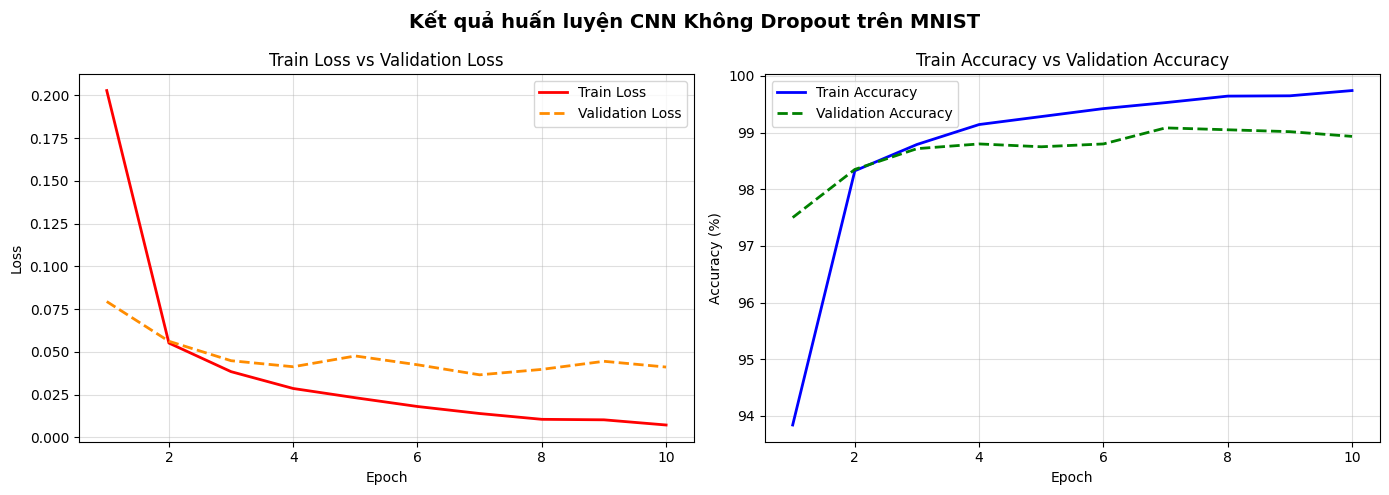

Đã lưu đồ thị vào 'nodropout_training_curves.png'


In [8]:
epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Kết quả huấn luyện CNN Không Dropout trên MNIST",
             fontsize=14, fontweight='bold')

# ── Loss ────────────────────────────────────────────────────
ax1 = axes[0]
ax1.plot(epochs_range, history['train_loss'],
         label='Train Loss',      color='red',       linewidth=2)
ax1.plot(epochs_range, history['val_loss'],
         label='Validation Loss', color='darkorange', linewidth=2, linestyle='--')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Train Loss vs Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.4)

# ── Accuracy ─────────────────────────────────────────────────
ax2 = axes[1]
ax2.plot(epochs_range, history['train_acc'],
         label='Train Accuracy',      color='blue',  linewidth=2)
ax2.plot(epochs_range, history['val_acc'],
         label='Validation Accuracy', color='green', linewidth=2, linestyle='--')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Train Accuracy vs Validation Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig('nodropout_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Đã lưu đồ thị vào 'nodropout_training_curves.png'")

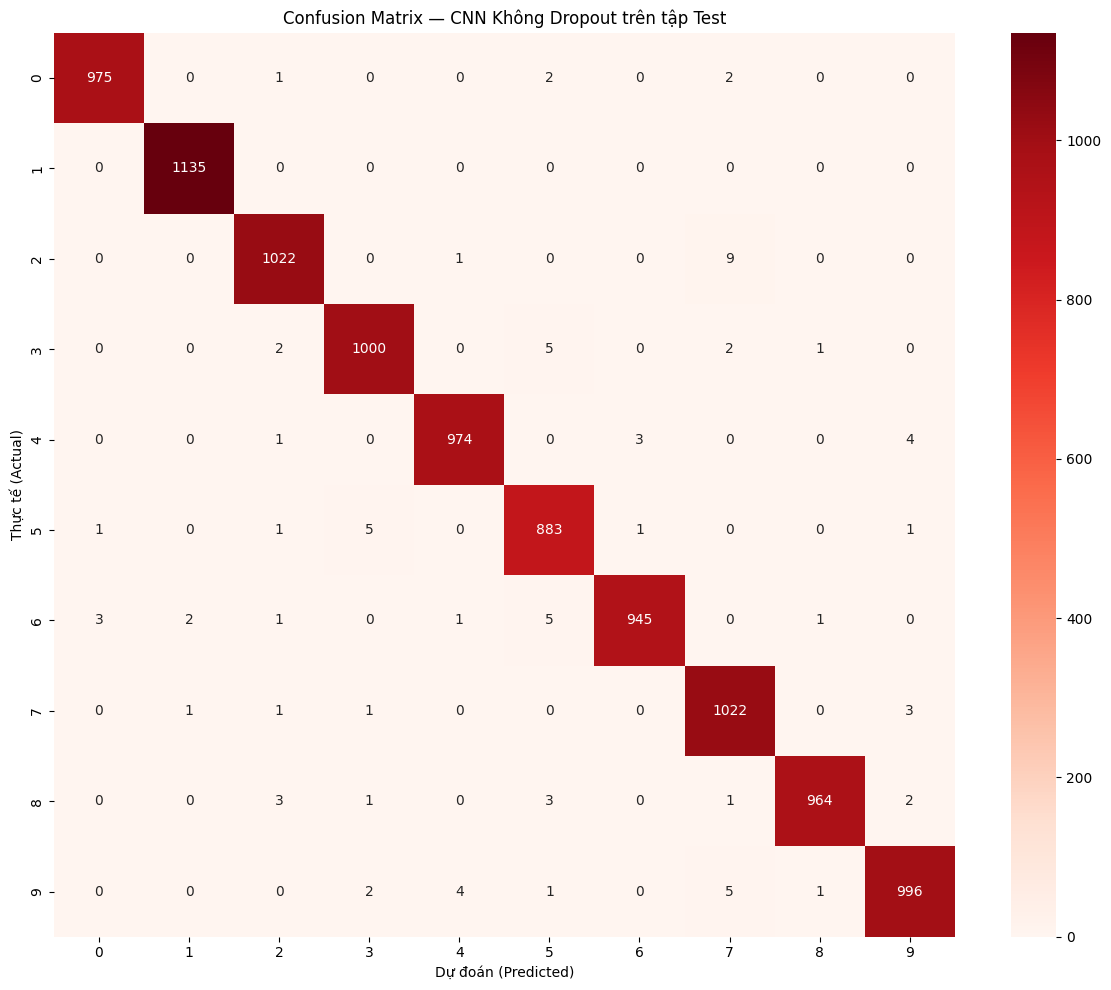


Classification Report — CNN Không Dropout:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       980
           1       1.00      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.98      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.98      0.99      0.99      1028
           8       1.00      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [9]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Thu thập toàn bộ dự đoán trên tập test
all_preds  = []
all_labels = []

test_model_nd.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = test_model_nd(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# ── 8.2 Confusion Matrix ────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',   # Dùng màu đỏ để phân biệt với BaseCNN (xanh)
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Dự đoán (Predicted)')
plt.ylabel('Thực tế (Actual)')
plt.title('Confusion Matrix — CNN Không Dropout trên tập Test')
plt.tight_layout()
plt.savefig('nodropout_confusion_matrix.png', dpi=150)
plt.show()

# ── 8.3 Classification Report ───────────────────────────────
print("\nClassification Report — CNN Không Dropout:")
print(classification_report(all_labels, all_preds,
                            target_names=[str(i) for i in range(10)]))

/tmp/ipykernel_950/2302109158.py:43: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_950/2302109158.py:43: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_950/2302109158.py:44: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('nodropout_sample_predictions.png', dpi=150)
/tmp/ipykernel_950/2302109158.py:44: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('nodropout_sample_predictions.png', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.prin

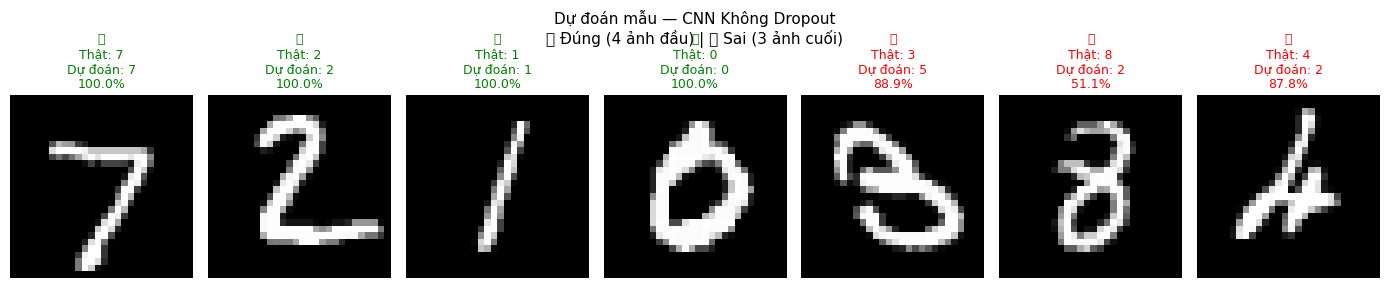

In [10]:
# Lấy 1 batch từ test_loader
sample_images, sample_labels = next(iter(test_loader))

test_model_nd.eval()
with torch.no_grad():
    outputs = test_model_nd(sample_images.to(device))
    probs   = torch.softmax(outputs, dim=1).cpu()  # Logits → xác suất
    preds   = probs.argmax(dim=1)

# Tìm index ảnh đúng và sai
correct_idx = (preds == sample_labels).nonzero(as_tuple=True)[0][:4]  # 4 ảnh đúng
wrong_idx   = (preds != sample_labels).nonzero(as_tuple=True)[0][:3]  # 3 ảnh sai
show_idx    = torch.cat([correct_idx, wrong_idx])

# Xử lý trường hợp model quá tốt, không đủ 3 ảnh sai trong 1 batch
if len(wrong_idx) < 3:
    print(f"⚠️  Chỉ tìm thấy {len(wrong_idx)} ảnh sai trong batch này.")
    print("   Model dự đoán quá tốt — đây là dấu hiệu có thể overfit.")
    show_idx = torch.cat([correct_idx, wrong_idx])

fig, axes = plt.subplots(1, len(show_idx), figsize=(14, 3))
fig.suptitle(
    'Dự đoán mẫu — CNN Không Dropout\n✅ Đúng (4 ảnh đầu) | ❌ Sai (3 ảnh cuối)',
    fontsize=11
)

for i, idx in enumerate(show_idx):
    img   = sample_images[idx].squeeze().numpy()
    true  = sample_labels[idx].item()
    pred  = preds[idx].item()
    prob  = probs[idx][pred].item() * 100
    is_ok = (true == pred)

    axes[i].imshow(img, cmap='gray')
    axes[i].axis('off')
    color = 'green' if is_ok else 'red'
    mark  = '✅' if is_ok else '❌'
    axes[i].set_title(
        f"{mark}\nThật: {true}\nDự đoán: {pred}\n{prob:.1f}%",
        color=color, fontsize=9
    )

plt.tight_layout()
plt.savefig('nodropout_sample_predictions.png', dpi=150)
plt.show()

In [11]:
# Lưu state_dict của model tốt nhất (đã load ở Cell 7)
torch.save(test_model_nd.state_dict(), 'NoDropoutCNN_final.pt')

print("── THÔNG TIN LƯU MODEL ─────────────────────────────────")
print(f"  Tên file        : NoDropoutCNN_final.pt")
print(f"  Định dạng       : PyTorch state_dict (.pt)")
print(f"  Val Loss tốt    : {best_val_loss:.4f}")
print(f"  Test Accuracy   : {test_acc:.2f}%")
print(f"  Khác BaseCNN    : Không có Dropout(0.25) và Dropout(0.5)")
print(f"  Dùng cho demo   : Tùy kết quả so sánh với BaseCNN")

── THÔNG TIN LƯU MODEL ─────────────────────────────────
  Tên file        : NoDropoutCNN_final.pt
  Định dạng       : PyTorch state_dict (.pt)
  Val Loss tốt    : 0.0366
  Test Accuracy   : 99.16%
  Khác BaseCNN    : Không có Dropout(0.25) và Dropout(0.5)
  Dùng cho demo   : Tùy kết quả so sánh với BaseCNN
